# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
import pandas as pd

In [2]:
exp_gen = np.random.normal(0, 1, 1000)
exp_gen

array([-6.30976284e-01, -8.27927586e-01,  1.42599785e+00, -1.21345891e+00,
       -7.74754653e-02,  6.87814393e-01, -1.17055479e+00,  6.13929465e-01,
        1.70571758e+00,  8.19134095e-02, -1.43375899e+00, -9.61046694e-01,
        3.31931094e-01, -1.50200902e+00,  3.04620845e-01,  1.18061898e+00,
       -3.58478289e-01, -2.88153876e-03,  5.81865778e-01, -9.50500941e-01,
        6.24689186e-01, -2.60859731e-01, -1.12687889e+00, -1.18221239e+00,
       -5.18265508e-01,  8.32349365e-01,  6.62827484e-02, -4.23934006e-01,
       -1.30757714e+00,  4.76577804e-01,  3.15312846e-02,  1.03176491e+00,
        1.54854082e+00, -4.17827599e-01, -1.02442500e+00, -1.09857382e-01,
       -8.47060247e-02, -8.26675869e-02, -4.10203349e-01, -4.33173985e-01,
        3.41951022e-01, -2.84799365e-01,  1.02022192e+00,  3.23635802e-01,
        2.98196999e-01,  5.11214575e-01,  1.38169201e+00, -2.47151726e-01,
       -3.83958877e-01, -4.78058445e-01,  2.81412669e-02,  1.10921389e+00,
       -2.76552507e-01, -

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [3]:
gen_pac = np.random.randint (1, 100, 1000)
gen_pac

array([86, 74, 16, 57, 48, 44, 77, 91,  5, 17, 57,  3, 62,  4, 82, 62, 55,
       91, 38, 58, 78, 12, 78, 53, 73, 23, 86,  7, 29, 50, 46, 46, 40, 78,
       46, 10, 97, 92, 59,  7, 57, 20, 42, 12, 64, 74, 81, 52, 47,  6, 39,
       62,  3, 88, 51, 93, 35, 40, 74, 99, 31, 50, 10, 46, 82, 68, 99, 43,
       66, 79, 58, 63, 94,  4,  3, 18, 67, 69, 45, 77, 92, 59, 45, 10, 43,
       86, 31, 38, 59,  4, 72,  9, 82, 97, 20, 15, 62, 59, 91, 35, 81, 54,
       67, 76, 22, 40, 77, 11, 59, 14,  7, 95, 24, 49, 89, 46, 38, 10, 99,
       39, 45, 44, 68, 44, 85, 76, 40,  3, 58, 90, 16, 27, 97, 82, 73, 40,
       30, 61,  8, 49, 30, 40, 61, 29, 82, 61,  5, 89, 17, 65, 91, 15,  2,
       57, 74, 97, 60, 97, 56, 60, 75, 82, 52, 81, 53, 98,  1, 19, 72, 74,
       97, 32, 79, 62, 34, 38, 95, 31, 99, 87, 46,  5, 69, 83, 25,  7,  1,
       20, 30, 18, 37, 72, 78, 52, 45, 50, 81, 52, 78, 77,  8, 45, 12, 15,
       73, 42, 63, 69, 79, 32, 26, 23, 39, 74, 75, 31, 54, 66, 62,  6, 42,
       63, 87, 57, 20, 43

In [4]:
df_ex2 = pd.DataFrame({
    "Genes": gen_pac,
    "Expressão relativa": exp_gen
})
df_ex2.head()

,Genes,Expressão relativa
0,86,-0.630976
1,74,-0.827928
2,16,1.425998
3,57,-1.213459
4,48,-0.077475


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Os dados serão divididos em níveis de expressão, de acordo com a distribuição interquartílica. Os grupos serão: ouliers inferiores, abaixo Q1, Q1 até mediana, mediana até Q3, acima de Q3, outliers superiores. Esses critérios foram escolhidos para observar uma estratificação exploratória da distribuição.

In [5]:
Q1 = df_ex2['Expressão relativa'].quantile(0.25)
Q2 = df_ex2['Expressão relativa'].quantile(0.50)
Q3 = df_ex2['Expressão relativa'].quantile(0.75)

IQR = Q3 - Q1
limite_inf = Q1 - 1.5*IQR
limite_sup = Q3 + 1.5*IQR

df_ex2['Grupo'] = 'NA'
df_ex2.loc[df_ex2['Expressão relativa'] < limite_inf, "Grupo"] = 'outlier_inf'
df_ex2.loc[
    (df_ex2['Expressão relativa'] >= limite_inf) &
    (df_ex2['Expressão relativa'] < Q1),
    "Grupo"] = 'baixo'
df_ex2.loc[
    (df_ex2['Expressão relativa'] >= Q1) &
    (df_ex2['Expressão relativa'] < Q2),
    "Grupo"] = 'Q1_mediana'
df_ex2.loc[
    (df_ex2['Expressão relativa'] >= Q2) &
    (df_ex2['Expressão relativa'] < Q3),
    "Grupo"] = 'mediana_Q3'
df_ex2.loc[
    (df_ex2['Expressão relativa'] >= Q3) &
    (df_ex2['Expressão relativa'] <= limite_sup),
    "Grupo"] = 'alto'
df_ex2.loc[df_ex2['Expressão relativa'] > limite_sup, "Grupo"] = 'outlier_sup'

ordem = [
    'outlier_inf',
    'baixo',
    'Q1_mediana',
    'mediana_Q3',
    'alto',
    'outlier_sup'
]
contagem = df_ex2['Grupo'].value_counts().reindex(ordem)

print(contagem)

Grupo
outlier_inf      3
baixo          247
Q1_mediana     250
mediana_Q3     250
alto           246
outlier_sup      4
Name: count, dtype: int64


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [7]:
def tabela_frequencia(serie: pd.Series) -> pd.DataFrame:
    freq_ab = serie.value_counts().sort_index()
    freq_rel = serie.value_counts(normalize=True).sort_index()
    tabela = pd.DataFrame({
        'Frequencia absoluta': freq_ab,
        'Frequencia relativa': (freq_rel * 100)
    })
    return tabela

In [9]:
freq_exp_gen = tabela_frequencia(df_ex2['Expressão relativa'])
freq_exp_gen

,Frequencia absoluta,Frequencia relativa
Expressão relativa,,
-2.949649,1,0.1
-2.795433,1,0.1
-2.783307,1,0.1
-2.537932,1,0.1
-2.525478,1,0.1
...,...,...
2.681767,1,0.1
2.758914,1,0.1
2.765542,1,0.1


In [10]:
freq_gen = tabela_frequencia(df_ex2['Genes'])
freq_gen

,Frequencia absoluta,Frequencia relativa
Genes,,
1,12,1.2
2,10,1.0
3,14,1.4
4,12,1.2
5,8,0.8
...,...,...
95,8,0.8
96,15,1.5
97,10,1.0


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

In [ ]:
import matplotlib.pyplot as plt

### Expressão

In [31]:
freq_gr = df_ex2['Expressão relativa'].value_counts()

In [21]:
freq_numeros = df_ex2['Genes'].value_counts()

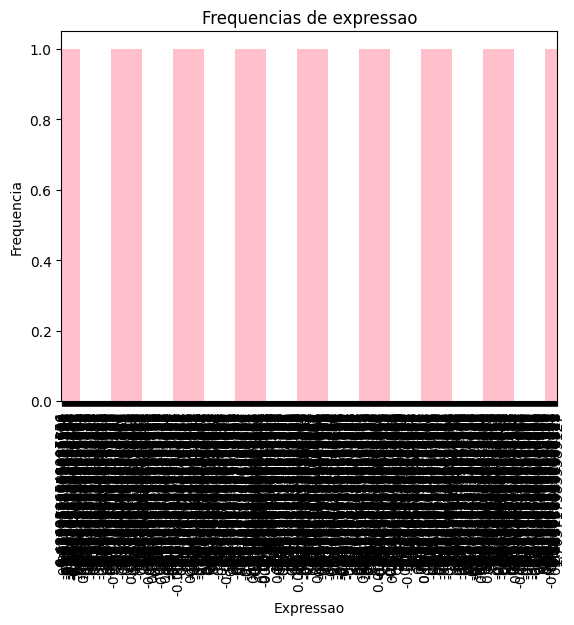

In [33]:
freq_gr.plot(kind='bar', color='pink')
plt.title("Frequencias de expressao")
plt.xlabel("Expressao")
plt.ylabel("Frequencia")
plt.show()

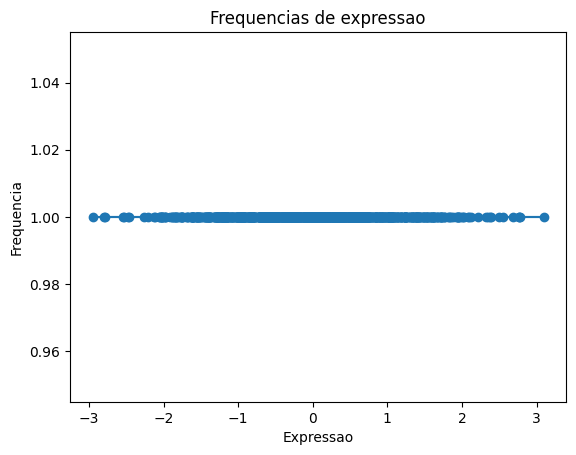

In [35]:
freq_gr.plot(kind='line', marker='o')
plt.title("Frequencias de expressao")
plt.xlabel("Expressao")
plt.ylabel("Frequencia")
plt.show()

### Número

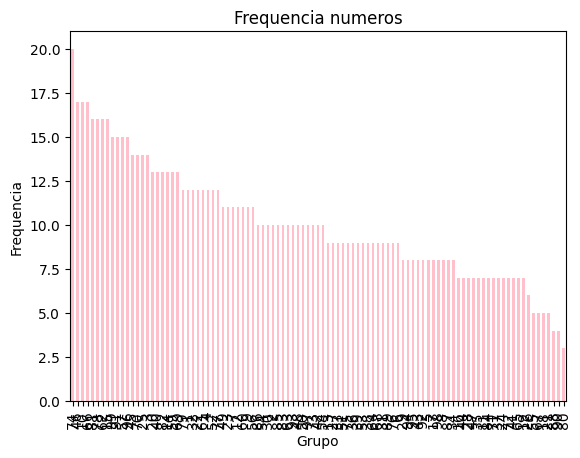

In [23]:
freq_numeros.plot(kind='bar', color='pink')
plt.title("Frequencia numeros")
plt.xlabel("Grupo")
plt.ylabel("Frequencia")
plt.show()

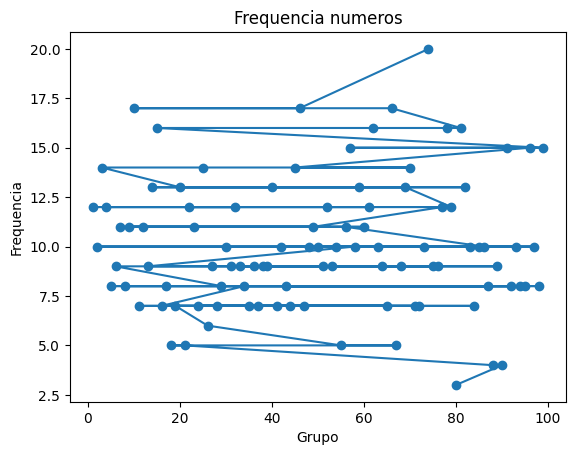

In [25]:
freq_numeros.plot(kind='line', marker='o')
plt.title("Frequencia numeros")
plt.xlabel("Grupo")
plt.ylabel("Frequencia")
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

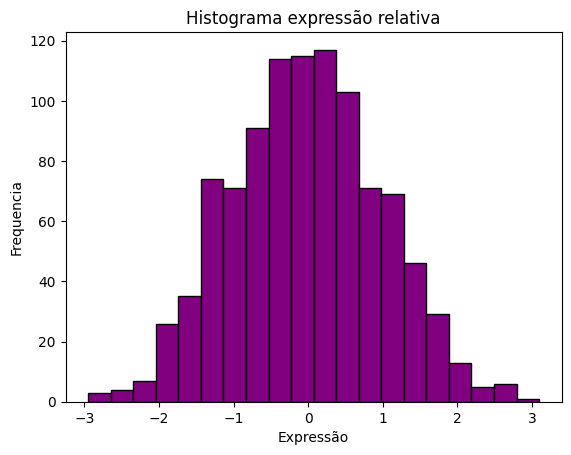

In [30]:
df_ex2['Expressão relativa'].plot(kind='hist', bins=20, color='purple', edgecolor='black')
plt.title("Histograma expressão relativa")
plt.xlabel("Expressão")
plt.ylabel("Frequencia")
plt.show()

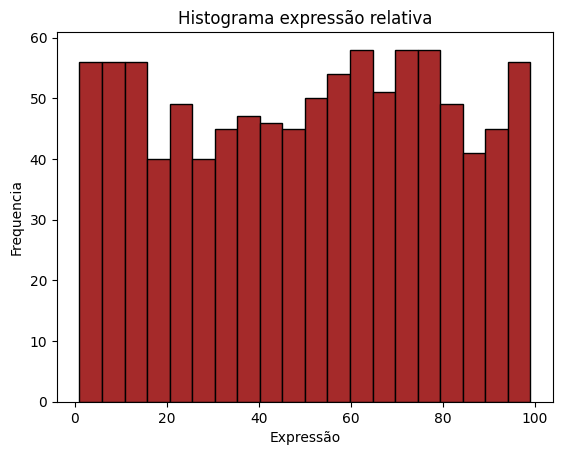

In [29]:
df_ex2['Genes'].plot(kind='hist', bins=20, color='brown', edgecolor='black')
plt.title("Histograma expressão relativa")
plt.xlabel("Expressão")
plt.ylabel("Frequencia")
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

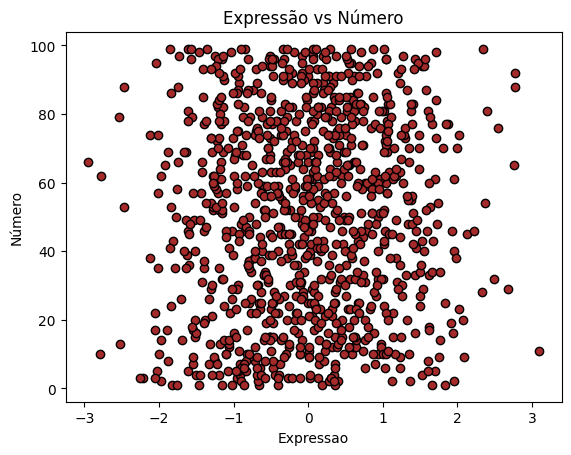

In [36]:
plt.scatter(df_ex2['Expressão relativa'], df_ex2['Genes'],
            color='brown', edgecolors='black')
plt.title('Expressão vs Número')
plt.xlabel('Expressao')
plt.ylabel('Número')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

In [39]:
ex8 = df_ex2['Grupo'].value_counts()
ex8

Grupo
Q1_mediana     250
mediana_Q3     250
baixo          247
alto           246
outlier_sup      4
outlier_inf      3
Name: count, dtype: int64

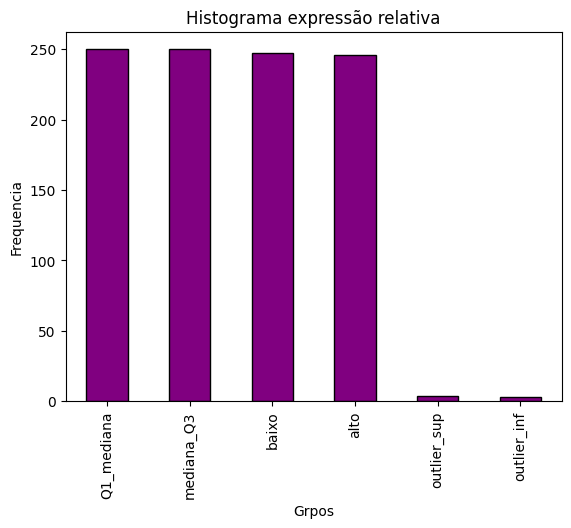

In [42]:
ex8.plot(kind='bar', color='purple', edgecolor='black')
plt.title("Histograma expressão relativa")
plt.xlabel("Grpos")
plt.ylabel("Frequencia")
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

In [43]:
import seaborn as sns


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



This is taking too long, we give up.



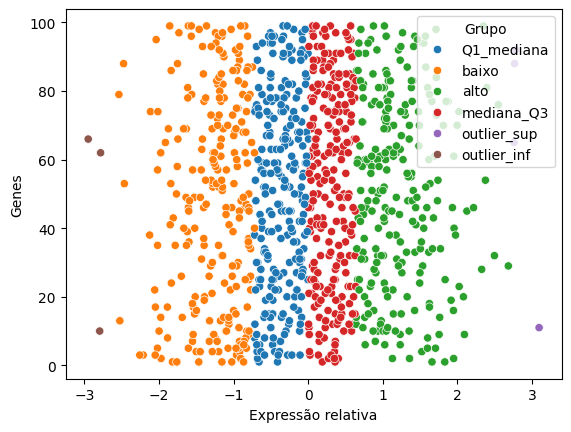

In [46]:
sns.scatterplot(
    data=df_ex2,
    x='Expressão relativa',
    y='Genes',
    hue='Grupo'
)
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|Discreta|
| % de células positivas|Contínua|
| Faixa de pH|Ordinal|
| Valor de pH|Contínua|
| mol/L|Contínua|
| UFC|Discreta|
| D.O.|Contínua|
| Grupo Sanguíneo|Nominal|
| Sorologia|Nominal|